# What Drives Movie Success? A TMDB-Based Analysis of Revenue and Blockbuster Outcomes

## Introduction

This analysis is designed for movie producers and investors who are interested in understanding what makes a movie financially successful. In particular, the project examines whether production scale, audience engagement, ratings, and film characteristics help explain both revenue and the likelihood that a movie becomes a blockbuster. This is a relevant question because producers and investors make high-stakes decisions about project selection, budgeting, and portfolio allocation under uncertainty, and data-driven evidence can improve those decisions.

To answer this question, we used two related datasets from The Movie Database (TMDB). The first dataset contains summary movie information such as popularity, vote average, and vote count, while the second dataset contains movie details such as budget, revenue, runtime, and genre information. By combining these sources, the analysis connects audience-facing metrics with business outcomes and uses exploratory data analysis and regression modeling to identify the factors most strongly associated with movie success.

## Data Collection

The project uses TMDB as the main data source. Two related datasets are collected through the API. The first dataset contains movie-level summary information such as title, popularity, vote average, vote count, and original language. The second dataset contains additional movie details such as runtime, budget, revenue, genre information, and production characteristics. Using both datasets improves the analysis by allowing movie performance measures to be connected with production and content variables.

In [1]:
# Import libraries for API requests, data cleaning, visualization, and modeling

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler

## Main Movie List Dataset

This section pulls the main movie list from TMDB's popular movie endpoint. The goal is to create an anchor dataset that captures broad audience-facing measures such as popularity, ratings, and vote counts across a sample of movies.

In [27]:
api_key = "2a413d515bdac6c2a86a12df96562f51"
movies_list = []
for page in range(1, 100):
    url = "https://api.themoviedb.org/3/movie/popular"
    params = {"api_key": api_key,"page": page}

    response = requests.get(url, params=params)
    data = response.json()

    for movie in data["results"]:
        movies_list.append({
            "movie_id": movie["id"],
            "title": movie["title"],
            "release_date": movie.get("release_date"),
            "popularity": movie.get("popularity"),
            "vote_average": movie.get("vote_average"),
            "vote_count": movie.get("vote_count"),
            "original_language": movie.get("original_language"),
            "adult": movie.get("adult"),
            "genre_ids": movie.get("genre_ids")
        })

movies_df = pd.DataFrame(movies_list)
movies_df.head()

,movie_id,title,release_date,popularity,vote_average,vote_count,original_language,adult,genre_ids
0,1265609,War Machine,2026-02-12,415.4914,6.869,229,en,False,"[28, 878, 53]"
1,1290821,Shelter,2026-01-28,373.4010,6.776,237,en,False,"[28, 80, 53]"
2,799882,The Bluff,2026-02-17,250.1719,6.259,214,en,False,"[28, 53]"
3,680493,Return to Silent Hill,2026-01-21,160.9873,5.024,250,en,False,"[9648, 18, 27]"
4,1159559,Scream 7,2026-02-25,151.1317,6.000,251,en,False,"[27, 9648, 80]"


## Movie Details Dataset

The second dataset adds movie-level details that are not available in the summary list. These include runtime, budget, revenue, genre information, and production characteristics. This second dataset is important because it provides the financial and structural variables needed for both exploratory analysis and regression modeling.

In [28]:
movie_details = []

for movie_id in movies_df["movie_id"]:
    url = f"https://api.themoviedb.org/3/movie/{movie_id}"
    params = {
        "api_key": api_key
    }

    response = requests.get(url, params=params)
    data = response.json()

    genres = data.get("genres", [])

    movie_details.append({
        "movie_id": movie_id,
        "runtime": data.get("runtime"),
        "budget": data.get("budget"),
        "revenue": data.get("revenue"),
        "status": data.get("status"),
        "genre_count": len(genres),
        "primary_genre": genres[0]["name"] if len(genres) > 0 else "Unknown",
        "production_company_count": len(data.get("production_companies", [])),
        "production_country_count": len(data.get("production_countries", [])),
        "spoken_language_count": len(data.get("spoken_languages", []))
    })

details_df = pd.DataFrame(movie_details)
details_df.head()

,movie_id,runtime,budget,revenue,status,genre_count,primary_genre,production_company_count,production_country_count,spoken_language_count
0,1265609,110,0,0,Released,3,Action,4,2,2
1,1290821,107,50000000,42079609,Released,3,Action,4,2,1
2,799882,102,0,0,Released,2,Action,3,1,1
3,680493,106,23000000,43023897,Released,3,Mystery,8,5,4
4,1159559,114,45000000,149474160,Released,3,Horror,3,1,1


## Data Merge

The movie list and movie details datasets are merged using `movie_id`, which acts as the unique key for each observation. This produces a single movie-level dataset that combines audience metrics with business and production variables.

In [29]:
movies = movies_df.merge(details_df, on="movie_id", how="left")
movies.head()

,movie_id,title,release_date,popularity,vote_average,vote_count,original_language,adult,genre_ids,runtime,budget,revenue,status,genre_count,primary_genre,production_company_count,production_country_count,spoken_language_count
0,1265609,War Machine,2026-02-12,415.4914,6.869,229,en,False,"[28, 878, 53]",110,0,0,Released,3,Action,4,2,2
1,1290821,Shelter,2026-01-28,373.4010,6.776,237,en,False,"[28, 80, 53]",107,50000000,42079609,Released,3,Action,4,2,1
2,799882,The Bluff,2026-02-17,250.1719,6.259,214,en,False,"[28, 53]",102,0,0,Released,2,Action,3,1,1
3,680493,Return to Silent Hill,2026-01-21,160.9873,5.024,250,en,False,"[9648, 18, 27]",106,23000000,43023897,Released,3,Mystery,8,5,4
4,1159559,Scream 7,2026-02-25,151.1317,6.000,251,en,False,"[27, 9648, 80]",114,45000000,149474160,Released,3,Horror,3,1,1


## Data Quality Checks

Before moving into analysis, we evaluated the quality of the merged dataset. This includes checking for missing values, identifying variables where zero likely represents unavailable data, checking for duplicate observations, and reviewing the number of unique values in key categorical variables. These checks help ensure that later analysis is based on variables that are valid and interpretable.

In [30]:
# Convert release date to datetime so year and month can be extracted later
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies["release_year"] = movies["release_date"].dt.year
movies["release_month"] = movies["release_date"].dt.month

# Convert relevant columns to numeric in case they were imported as text
numeric_columns = [
    "popularity", "vote_average", "vote_count", "runtime",
    "budget", "revenue", "genre_count",
    "production_company_count", "production_country_count",
    "spoken_language_count"
]

for col in numeric_columns:
    movies[col] = pd.to_numeric(movies[col], errors="coerce")

In [31]:
zero_missing_cols = ["budget", "revenue", "runtime", "vote_count"]

zero_counts = movies[zero_missing_cols].eq(0).sum()

print("Zero values detected in key variables:")
print(zero_counts)

movies[zero_missing_cols] = movies[zero_missing_cols].replace(0, np.nan)

missing_counts = movies.isnull().sum()

missing_table = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": (missing_counts / len(movies)) * 100
})

missing_table["valid_percent"] = 100 - missing_table["missing_percent"]

missing_table = missing_table.sort_values("missing_percent", ascending=False)

missing_table

Zero values detected in key variables:
budget        1552
revenue       1566
runtime        171
vote_count     362
dtype: int64


,missing_count,missing_percent,valid_percent
revenue,1566,79.090909,20.909091
budget,1552,78.383838,21.616162
vote_count,362,18.282828,81.717172
runtime,171,8.636364,91.363636
release_month,18,0.909091,99.090909
release_year,18,0.909091,99.090909
release_date,18,0.909091,99.090909
movie_id,0,0.000000,100.000000
popularity,0,0.000000,100.000000
title,0,0.000000,100.000000


In [32]:
# Check for duplicate movie IDs to confirm each movie appears only once
print("Number of duplicate movie_id values:", movies["movie_id"].duplicated().sum())

Number of duplicate movie_id values: 0


In [33]:
# Review unique values in important categorical columns as a general validity check
print("Unique languages:", movies["original_language"].nunique())
print("Unique statuses:", movies["status"].nunique())
print("Unique primary genres:", movies["primary_genre"].nunique())

Unique languages: 45
Unique statuses: 5
Unique primary genres: 20


In [139]:
# Remove movies with runtime less than an hour (e.g. movies with runtime 1 minute, data collection error)
movies = movies[movies["runtime"] >= 60]

In [140]:
movies[[
    "popularity", "vote_average", "vote_count",
    "runtime", "budget", "revenue"
]].describe()

,popularity,vote_average,vote_count,runtime,budget,revenue
count,1580.000000,1580.000000,1419.000000,1580.000000,4.200000e+02,4.120000e+02
mean,22.860358,5.499704,1907.660324,103.572152,6.180485e+07,2.878051e+08
std,19.405096,2.348917,5459.160152,28.875316,7.504964e+07,4.488571e+08
min,16.343200,0.000000,1.000000,60.000000,1.700000e+01,2.000000e+00
25%,17.135125,4.800000,6.000000,88.000000,7.000000e+06,8.185957e+06
50%,18.537000,6.100000,28.000000,97.000000,3.300000e+07,1.012393e+08
75%,22.441900,7.002250,320.500000,112.000000,9.000000e+07,3.814416e+08
max,415.491400,10.000000,39060.000000,400.000000,4.650000e+08,2.923706e+09


## Feature Engineering

To improve the analysis, we created several new variables from the original data. These include a blockbuster indicator, log-transformed financial variables, grouped runtime categories, language groups, and interaction terms. These engineered variables are intended to make the data more interpretable and to provide inputs that better reflect the underlying business relationships in the movie industry.

In [141]:
movies["blockbuster"] = (movies["revenue"] >= 100_000_000).astype(int)

movies["profit"] = movies["revenue"] - movies["budget"]

movies["roi"] = np.where(
    movies["budget"] > 0,
    movies["revenue"] / movies["budget"],
    np.nan
)
# Log-transform highly skewed variables to reduce the influence of extreme values
movies["log_revenue"] = np.log1p(movies["revenue"])
movies["log_budget"] = np.log1p(movies["budget"])
movies["log_vote_count"] = np.log1p(movies["vote_count"])

movies["budget_per_minute"] = np.where(
    movies["runtime"] > 0,
    movies["budget"] / movies["runtime"],
    np.nan
)

movies["high_rating"] = (movies["vote_average"] >= 7).astype(int)

In [142]:
# Create runtime categories using apply to support grouped analysis
movies["runtime_group"] = movies["runtime"].apply(
    lambda x: "Short" if pd.notnull(x) and x < 90
    else "Medium" if pd.notnull(x) and x < 120
    else "Long" if pd.notnull(x)
    else "Unknown"
)

In [143]:
language_map = {
    "en": "English",
    "es": "Spanish",
    "fr": "French",
    "ja": "Japanese",
    "ko": "Korean"
}

movies["language_group"] = movies["original_language"].map(language_map).fillna("Other")

In [144]:
# Cap extreme values at the 99th percentile for visualization so a few blockbusters do not dominate the plots
movies["revenue_capped"] = movies["revenue"].clip(
    upper=movies["revenue"].quantile(0.99))

movies["budget_capped"] = movies["budget"].clip(
    upper=movies["budget"].quantile(0.99))

movies["vote_count_capped"] = movies["vote_count"].clip(
    upper=movies["vote_count"].quantile(0.99))

## Exploratory Data Analysis

The exploratory analysis focuses on patterns that are relevant to producers and investors. In particular, we examined how movie performance varies across genres, runtime groups, and language groups, and visualized the relationships between budget, revenue, popularity, and audience engagement. The goal is to identify patterns that may help explain movie success before moving into predictive models.

In [145]:
# Aggregate movie outcomes by primary genre to compare average performance across categories
genre_table = movies.groupby("primary_genre").agg(
    movie_count=("movie_id", "count"),
    avg_revenue=("revenue", "mean"),
    avg_popularity=("popularity", "mean"),
    avg_vote_average=("vote_average", "mean"),
    blockbuster_rate=("blockbuster", "mean")
).sort_values("movie_count", ascending=False)

genre_table

,movie_count,avg_revenue,avg_popularity,avg_vote_average,blockbuster_rate
primary_genre,,,,,
Drama,375,1.429212e+08,20.559069,5.431141,0.069333
Comedy,263,1.231907e+08,20.522158,5.167475,0.060837
Action,157,4.513171e+08,32.407865,6.031000,0.273885
Documentary,118,1.071742e+06,19.458657,5.344610,0.000000
Horror,107,1.254542e+08,24.592608,5.135664,0.149533
Animation,62,4.709011e+08,28.493202,7.213097,0.435484
Thriller,52,1.965205e+08,27.456888,5.537654,0.115385
Adventure,51,6.094562e+08,23.395888,6.500569,0.509804
Romance,51,9.566807e+07,21.595751,5.312294,0.098039


In [146]:
# Compare runtime groups to see whether movie length is associated with revenue or popularity
runtime_table = movies.groupby("runtime_group").agg(
    movie_count=("movie_id", "count"),
    avg_runtime=("runtime", "mean"),
    avg_revenue=("revenue", "mean"),
    avg_popularity=("popularity", "mean"))

runtime_table

,movie_count,avg_runtime,avg_revenue,avg_popularity
runtime_group,,,,
Long,292,148.708904,4.656869e+08,23.384630
Medium,842,100.147268,1.820994e+08,23.817931
Short,446,80.486547,1.117310e+08,20.709318


In [147]:
# Examine language groups to check whether outcomes vary across international segments
language_table = movies.groupby("language_group").agg(
    movie_count=("movie_id", "count"),
    avg_revenue=("revenue", "mean"),
    avg_vote_average=("vote_average", "mean")
).sort_values("movie_count", ascending=False)

language_table

,movie_count,avg_revenue,avg_vote_average
language_group,,,
English,965,3.382508e+08,5.750818
Other,398,7.764608e+07,4.908643
Spanish,103,7.436184e+06,5.062194
French,90,1.943946e+07,5.768489
Japanese,17,2.750357e+08,5.708471
Korean,7,1.112488e+08,6.962857


In [126]:
# Visualize pairwise relationships between financial and audience variables
correlation_table = movies[[
    "popularity", "vote_average", "vote_count",
    "runtime", "budget", "revenue", "roi"
]].corr()

correlation_table

,popularity,vote_average,vote_count,runtime,budget,revenue,roi
popularity,1.000000,0.088067,-0.000305,0.040461,0.079556,0.027841,0.044567
vote_average,0.088067,1.000000,0.359396,0.160496,0.281731,0.336371,-0.085215
vote_count,-0.000305,0.359396,1.000000,0.376391,0.421415,0.596627,-0.043610
runtime,0.040461,0.160496,0.376391,1.000000,0.397442,0.384950,-0.064633
budget,0.079556,0.281731,0.421415,0.397442,1.000000,0.708060,-0.049328
revenue,0.027841,0.336371,0.596627,0.384950,0.708060,1.000000,-0.033090
roi,0.044567,-0.085215,-0.043610,-0.064633,-0.049328,-0.033090,1.000000


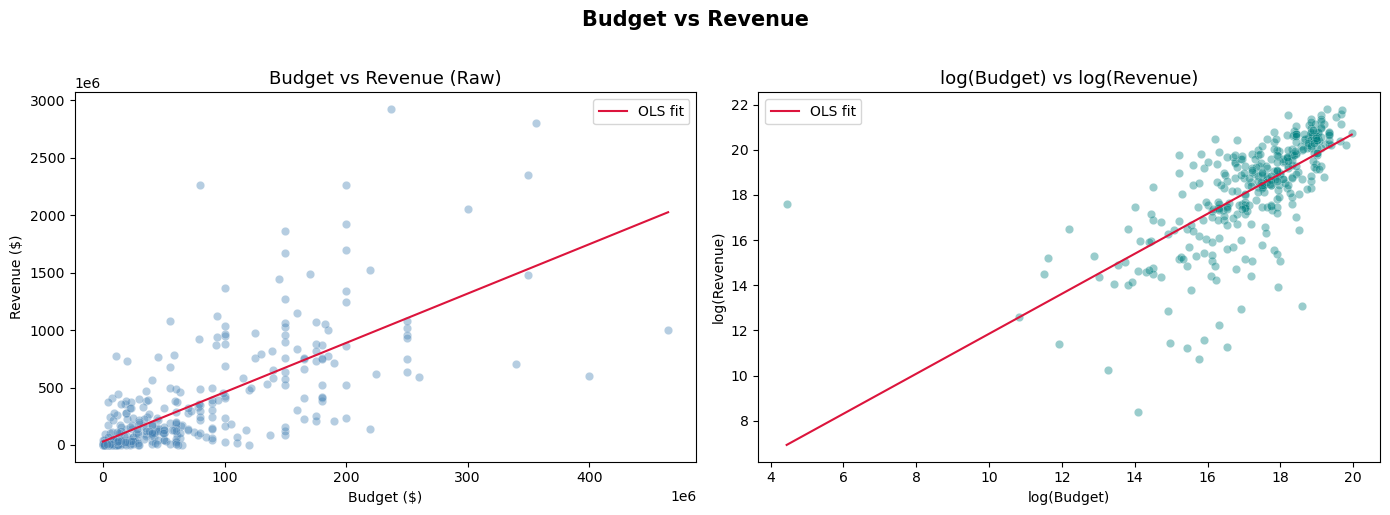

In [138]:
# Visualize relationship between budget and revenue to examine whether large budget movies generally generate high revenue
plot_data = movies[["budget", "revenue", "log_budget", "log_revenue"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw: Budget vs Revenue
axes[0].scatter(plot_data["budget"], plot_data["revenue"], alpha=0.4, color="steelblue", edgecolors="white", linewidths=0.3)
m, b = np.polyfit(plot_data["budget"], plot_data["revenue"], 1)
x_line = np.linspace(plot_data["budget"].min(), plot_data["budget"].max(), 100)
axes[0].plot(x_line, m * x_line + b, color="crimson", linewidth=1.5, label="OLS fit")
axes[0].set_title("Budget vs Revenue (Raw)", fontsize=13)
axes[0].set_xlabel("Budget ($)")
axes[0].set_ylabel("Revenue ($)")
axes[0].legend()
axes[0].ticklabel_format(style="sci", axis="both", scilimits=(6, 6))

# Log-transformed: log_budget vs log_revenue
axes[1].scatter(plot_data["log_budget"], plot_data["log_revenue"], alpha=0.4, color="teal", edgecolors="white", linewidths=0.3)
m2, b2 = np.polyfit(plot_data["log_budget"], plot_data["log_revenue"], 1)
x_line2 = np.linspace(plot_data["log_budget"].min(), plot_data["log_budget"].max(), 100)
axes[1].plot(x_line2, m2 * x_line2 + b2, color="crimson", linewidth=1.5, label="OLS fit")
axes[1].set_title("log(Budget) vs log(Revenue)", fontsize=13)
axes[1].set_xlabel("log(Budget)")
axes[1].set_ylabel("log(Revenue)")
axes[1].legend()

plt.suptitle("Budget vs Revenue", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

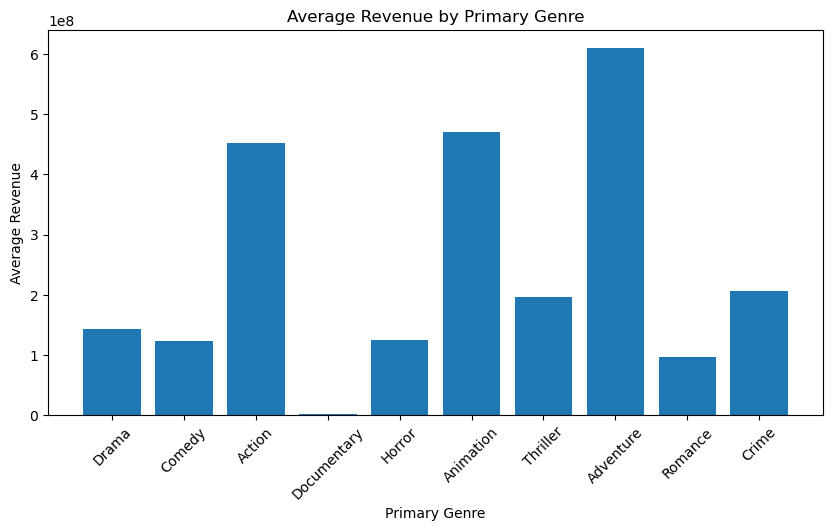

In [128]:
# Compare revenue across genre
top_genres = genre_table.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_genres.index, top_genres["avg_revenue"])
plt.title("Average Revenue by Primary Genre")
plt.xlabel("Primary Genre")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.show()

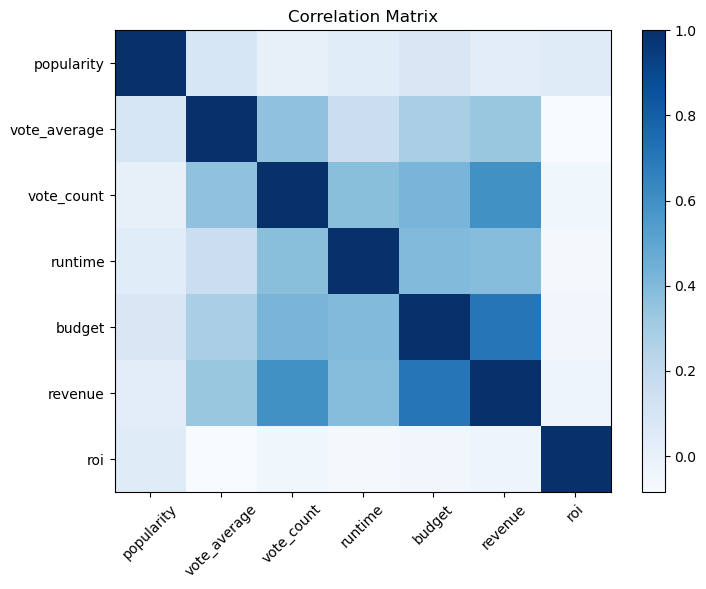

In [129]:
# Use a correlation matrix to summarize linear relationships among key numeric variables
corr_matrix = movies[[
    "popularity", "vote_average", "vote_count",
    "runtime", "budget", "revenue", "roi"
]].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="Blues", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

## Linear Regression Model

The first model uses linear regression to predict log revenue. Log revenue is used instead of raw revenue because the original revenue variable is highly right-skewed. The model includes both original and engineered predictors, such as log budget, log vote count, runtime, vote average, genre count, and the interaction between popularity and rating.

In [130]:
model_data = movies[[
    "revenue",
    "log_revenue",
    "blockbuster",
    "budget_capped",
    "runtime",
    "vote_average",
    "vote_count_capped",
    "genre_count",
    "production_company_count",
    "spoken_language_count",
    "high_rating",
    "log_budget",
    "log_vote_count"
]].dropna()

In [131]:
model_data.info()

<class 'pandas.DataFrame'>
Index: 352 entries, 1 to 1971
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   revenue                   352 non-null    float64
 1   log_revenue               352 non-null    float64
 2   blockbuster               352 non-null    int64  
 3   budget_capped             352 non-null    float64
 4   runtime                   352 non-null    float64
 5   vote_average              352 non-null    float64
 6   vote_count_capped         352 non-null    float64
 7   genre_count               352 non-null    int64  
 8   production_company_count  352 non-null    int64  
 9   spoken_language_count     352 non-null    int64  
 10  high_rating               352 non-null    int64  
 11  log_budget                352 non-null    float64
 12  log_vote_count            352 non-null    float64
dtypes: float64(8), int64(5)
memory usage: 38.5 KB


In [132]:
# Split the data into training and test sets so performance can be evaluated on unseen data
X = model_data[[
    "log_budget",
    "runtime",
    "vote_average",
    "log_vote_count",
    "genre_count",
    "spoken_language_count",
    "high_rating",
]]

y = model_data["log_revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

train_pred = linear_model.predict(X_train)
test_pred = linear_model.predict(X_test)

print("Linear Regression Results")
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))
print("MAE:", mean_absolute_error(y_test, test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))

linear_coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": linear_model.coef_
}).sort_values("Coefficient", ascending=False)

linear_coefficients

Linear Regression Results
Train R2: 0.6401144260589167
Test R2: 0.6541088945924642
MAE: 0.8892892221467426
RMSE: 1.2420152953258108


,Variable,Coefficient
3,log_vote_count,0.548921
0,log_budget,0.466622
4,genre_count,0.267648
2,vote_average,0.199411
1,runtime,0.001272
6,high_rating,-0.048923
5,spoken_language_count,-0.145666


### Linear Regression Interpretation

The linear regression results suggest that production scale and audience engagement are the strongest predictors of movie revenue. In particular, budget and vote count show the clearest positive relationship with revenue. This is consistent with the idea that larger productions and more visible movies tend to generate stronger commercial outcomes.

In [133]:
r2 = r2_score(y_test, test_pred)
n = len(y_test)
k = X.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print("Adjusted R2:", adjusted_r2)

Adjusted R2: 0.6156765495471825


## Logistic Regression Model

The second model uses logistic regression to predict whether a movie becomes a blockbuster. This is relevant for decision-makers because blockbuster status is often a practical threshold for evaluating whether a film achieved major commercial success. The model uses the same business-relevant features as the linear regression and includes engineered variables.

In [134]:
X = model_data[[
    "log_budget",
    "runtime",
    "vote_average",
    "genre_count",
    "production_company_count",
    "spoken_language_count",
    "high_rating",
]]

y = model_data["blockbuster"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred, zero_division=0))
print("Recall:", recall_score(y_test, log_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, log_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, log_pred))

Logistic Regression Results
Accuracy: 0.8873239436619719
Precision: 0.9047619047619048
Recall: 0.9047619047619048
F1 Score: 0.9047619047619048
Confusion Matrix:
[[25  4]
 [ 4 38]]


In [135]:
log_coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

log_coefficients

,Variable,Coefficient
0,log_budget,1.850302
2,vote_average,0.690967
1,runtime,0.062920
3,genre_count,-0.043834
6,high_rating,-0.082114
4,production_company_count,-0.117282
5,spoken_language_count,-0.243845


### Logistic Regression Interpretation

The logistic regression model provides a way to classify whether a movie is likely to become a blockbuster. Variables related to scale, attention, and audience response appear to be the most useful predictors. This is relevant for producers and investors because blockbuster status is often more actionable than raw revenue alone.

## Conclusion

This project examined what makes a movie successful using TMDB data and focused on an audience of movie producers and investors. Overall, the analysis suggests that production scale and audience engagement are the strongest predictors of commercial success. Budget, vote count, and related engineered features were especially useful in explaining both revenue and blockbuster outcomes. These findings imply that both investment size and audience visibility play an important role in movie performance.

At the same time, the project has limitations. TMDB popularity is a platform-specific metric and may not fully capture broader market demand, and the dataset is limited to films retrieved through the API rather than the entire movie market. If there were more time, we would expand the analysis using additional datasets such as box office reporting data, marketing spend, franchise indicators, streaming platform availability, critic review data, and award nominations. These additions would likely improve both the explanatory power of the models and the practical relevance of the results for decision-makers in the film industry.